In [1]:
#Import all libraries

import pandas as pd
import numpy as np
import re

from datasets import load_dataset

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout

from sklearn.model_selection import train_test_split

In [2]:
#Load the Stanford Sentiment Treebank 2 dataset

data = load_dataset("glue","sst2")
df = pd.DataFrame(data['train'])


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

sst2/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

sst2/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

sst2/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

In [3]:
#Viewing the dataset with labels

df = df[["sentence","label"]]
df.head()

,sentence,label
0,hide new secretions from the parental units,0
1,"contains no wit , only labored gags",0
2,that loves its characters and communicates som...,1
3,remains utterly satisfied to remain the same t...,0
4,on the worst revenge-of-the-nerds clichés the ...,0


In [5]:
# X-> input sentences , y-> output labels

X = df['sentence']
y = df['label']

In [6]:
X.shape

(67349,)

In [7]:
# Tokenization

token = Tokenizer(num_words=10000)
token.fit_on_texts(X)

Xsequences = token.texts_to_sequences(X)

In [11]:
# Padding

max = 40
Xpadded = pad_sequences(Xsequences, maxlen = max)

In [12]:
# Train/Test Split

Xtrain, Xtest, ytrain, ytest = train_test_split(Xpadded,y, test_size=0.2,random_state=40)

In [13]:
# RNN Model Building

model = Sequential()
model.add(Embedding(input_dim=10000, output_dim=32))
model.add(SimpleRNN(32, dropout=0.5))
model.add(Dense(1, activation="sigmoid"))

model.build(input_shape=(None, max))

In [14]:
# Compile the model

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 40, 32)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 322,113 (1.23 MB)

 Trainable params: 322,113 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
hist = model.fit(
    Xtrain,
    ytrain,
    epochs=5,
    batch_size=32,
    validation_data=(Xtest,ytest)
)

Epoch 1/5
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.7864 - loss: 0.4388 - val_accuracy: 0.8726 - val_loss: 0.3089
Epoch 2/5
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9002 - loss: 0.2522 - val_accuracy: 0.8990 - val_loss: 0.2584
Epoch 3/5
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9223 - loss: 0.2011 - val_accuracy: 0.9088 - val_loss: 0.2431
Epoch 4/5
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9318 - loss: 0.1776 - val_accuracy: 0.9107 - val_loss: 0.2437
Epoch 5/5
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9395 - loss: 0.1598 - val_accuracy: 0.9148 - val_loss: 0.2461


In [16]:
# Calculate Validation Accuracy

loss,accuracy = model.evaluate(Xtest,ytest)

421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9148 - loss: 0.2461


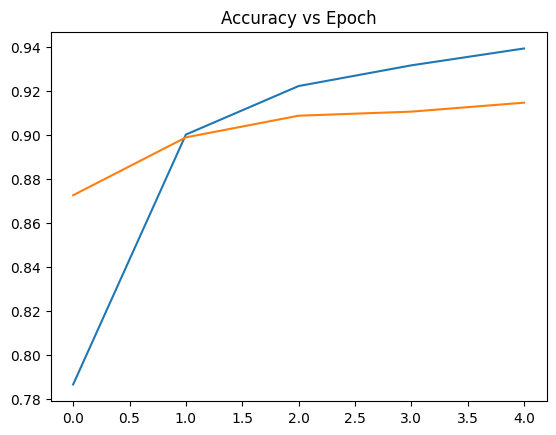

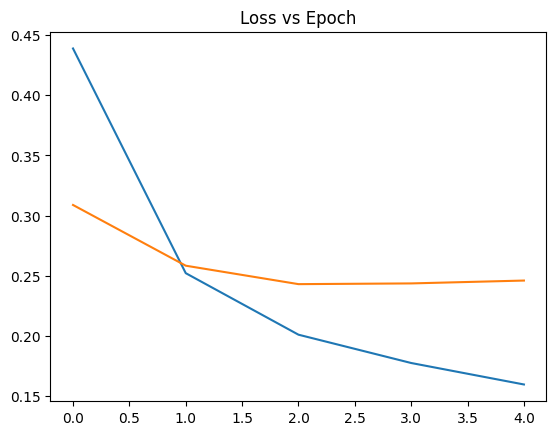

In [17]:
import matplotlib.pyplot as plt

plt.plot(hist.history['accuracy']); plt.plot(hist.history['val_accuracy'])
plt.title("Accuracy vs Epoch"); plt.show()

plt.plot(hist.history['loss']); plt.plot(hist.history['val_loss'])
plt.title("Loss vs Epoch"); plt.show()

In [ ]:
# Custom input prediction
s = input("Enter a sentence: ").lower()

seq = token.texts_to_sequences([s])

padded = pad_sequences(seq,maxlen=max)

prediction = model.predict(padded)

if prediction[0][0] > 0.5:
    print("Sentiment: Positive :)")
else:
    print("Sentiment: Negative :(")

Enter a sentence: i was not happy with the product
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Sentiment: Negative :(


In [19]:
# LSTM Model Building, Compiling & Training

from tensorflow.keras.layers import LSTM

lstm_model = Sequential()
lstm_model.add(Embedding(input_dim=10000, output_dim=32))
lstm_model.add(LSTM(32, dropout=0.5))
lstm_model.add(Dense(1, activation="sigmoid"))

lstm_model.build(input_shape=(None, m))

lstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=['accuracy']
)

lstm_model.summary()

lstm_hist = lstm_model.fit(
    Xtrain,
    ytrain,
    epochs=5,
    batch_size=32,
    validation_data=(Xtest, ytest)
)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 40, 32)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 328,353 (1.25 MB)

 Trainable params: 328,353 (1.25 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - accuracy: 0.8023 - loss: 0.4105 - val_accuracy: 0.8881 - val_loss: 0.2780
Epoch 2/5
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9009 - loss: 0.2442 - val_accuracy: 0.8993 - val_loss: 0.2663
Epoch 3/5
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9191 - loss: 0.2044 - val_accuracy: 0.9083 - val_loss: 0.2416
Epoch 4/5
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9291 - loss: 0.1802 - val_accuracy: 0.9130 - val_loss: 0.2349
Epoch 5/5
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9366 - loss: 0.1620 - val_accuracy: 0.9141 - val_loss: 0.2474


In [20]:
# GRU Model Building, Compiling & Training

from tensorflow.keras.layers import GRU

gru_model = Sequential()
gru_model.add(Embedding(input_dim=10000, output_dim=32))
gru_model.add(GRU(32, dropout=0.5))
gru_model.add(Dense(1, activation="sigmoid"))

gru_model.build(input_shape=(None, m))

gru_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=['accuracy']
)

gru_model.summary()

gru_hist = gru_model.fit(
    Xtrain,
    ytrain,
    epochs=5,
    batch_size=32,
    validation_data=(Xtest, ytest)
)

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 40, 32)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 32)             │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 326,369 (1.24 MB)

 Trainable params: 326,369 (1.24 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8067 - loss: 0.4052 - val_accuracy: 0.8887 - val_loss: 0.2694
Epoch 2/5
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9050 - loss: 0.2380 - val_accuracy: 0.9037 - val_loss: 0.2458
Epoch 3/5
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9217 - loss: 0.1976 - val_accuracy: 0.9079 - val_loss: 0.2419
Epoch 4/5
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9311 - loss: 0.1752 - val_accuracy: 0.9126 - val_loss: 0.2368
Epoch 5/5
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9376 - loss: 0.1593 - val_accuracy: 0.9140 - val_loss: 0.2379


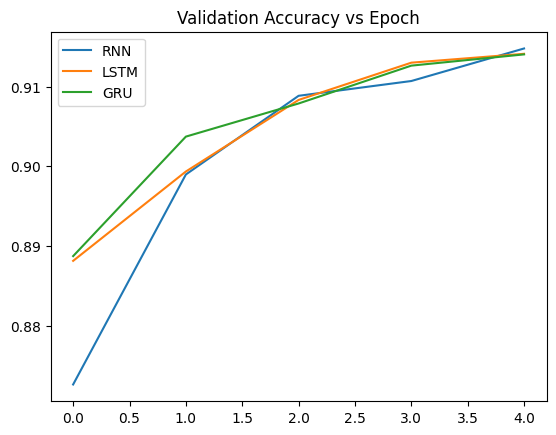

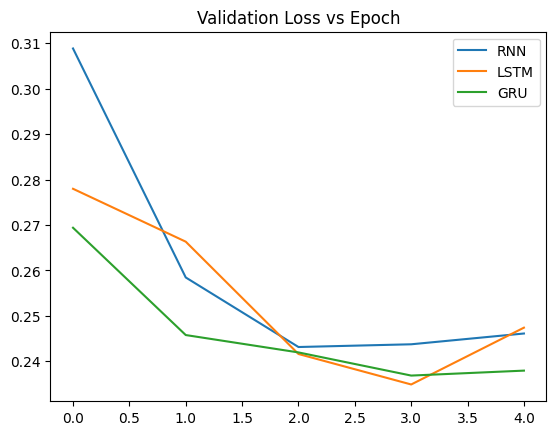

In [21]:
# Compare RNN vs LSTM vs GRU

import matplotlib.pyplot as plt

# Accuracy Comparison
plt.plot(hist.history['val_accuracy'], label='RNN')
plt.plot(lstm_hist.history['val_accuracy'], label='LSTM')
plt.plot(gru_hist.history['val_accuracy'], label='GRU')
plt.title("Validation Accuracy vs Epoch")
plt.legend(); plt.show()

# Loss Comparison
plt.plot(hist.history['val_loss'], label='RNN')
plt.plot(lstm_hist.history['val_loss'], label='LSTM')
plt.plot(gru_hist.history['val_loss'], label='GRU')
plt.title("Validation Loss vs Epoch")
plt.legend(); plt.show()